***Prepare Data***


**Import**

In [36]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error



In [54]:
df = pd.read_csv("/workspaces/Machine-Learining-Models/day_002_logistic_regression/data/Telecom.xlsx - Telecom.csv")

In [55]:
df.head(10)

,SN,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1869,7010-BRBUU,Male,0,Yes,Yes,72,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.10,1734.65,No
1,4528,9688-YGXVR,Female,0,No,No,44,Yes,No,Fiber optic,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),88.15,3973.2,No
2,6344,9286-DOJGF,Female,1,Yes,No,38,Yes,Yes,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),74.95,2869.85,Yes
3,6739,6994-KERXL,Male,0,No,No,4,Yes,No,DSL,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,55.90,238.5,No
4,432,2181-UAESM,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,Month-to-month,No,Electronic check,53.45,119.5,No
5,2215,4312-GVYNH,Female,0,Yes,No,70,No,No phone service,DSL,...,Yes,Yes,No,Yes,Two year,Yes,Bank transfer (automatic),49.85,3370.2,No
6,5260,2495-KZNFB,Female,0,No,No,33,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,90.65,2989.6,No
7,6001,4367-NHWMM,Female,0,No,No,1,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,24.90,24.9,No
8,1480,8898-KASCD,Male,0,No,No,39,No,No phone service,DSL,...,Yes,Yes,No,No,One year,No,Mailed check,35.55,1309.15,No
9,5137,8016-NCFVO,Male,1,No,No,55,Yes,Yes,Fiber optic,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,116.50,6382.55,No


**Explore**

In [64]:
def wrangle_data(df_raw):
    
    # Create a copy 
    df = df1.copy()
    # convert total charge to a number
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce').fillna(0)
    
    # Drop irrelevant/redundant columns
    cols_to_drop = ['SN', 'customerID', 'TotalCharges']
    df = df.drop(columns=cols_to_drop)
    
    # Convert 'Yes'/'No' to 1/0 for math compatibility
    df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})
    df['Churn'] = df['Churn'].astype(int)  # ensure integer
    
    # Type Conversion
    # Treat SeniorCitizen as categorical rather than numerical
    df['SeniorCitizen'] = df['SeniorCitizen'].astype('category')
    
    # Standardize column names or values

    # df.columns = df.columns.str.lower()
    
    return df

df = wrangle_data(df)

In [65]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,Male,0,Yes,Yes,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.10,0
1,Female,0,No,No,44,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),88.15,0
2,Female,1,Yes,No,38,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),74.95,1
3,Male,0,No,No,4,Yes,No,DSL,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,55.90,0
4,Male,0,No,No,2,Yes,No,DSL,Yes,No,Yes,No,No,No,Month-to-month,No,Electronic check,53.45,0


In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5986 entries, 0 to 5985
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            5986 non-null   str     
 1   SeniorCitizen     5986 non-null   category
 2   Partner           5986 non-null   str     
 3   Dependents        5986 non-null   str     
 4   tenure            5986 non-null   int64   
 5   PhoneService      5986 non-null   str     
 6   MultipleLines     5986 non-null   str     
 7   InternetService   5986 non-null   str     
 8   OnlineSecurity    5986 non-null   str     
 9   OnlineBackup      5986 non-null   str     
 10  DeviceProtection  5986 non-null   str     
 11  TechSupport       5986 non-null   str     
 12  StreamingTV       5986 non-null   str     
 13  StreamingMovies   5986 non-null   str     
 14  Contract          5986 non-null   str     
 15  PaperlessBilling  5986 non-null   str     
 16  PaymentMethod     5986 non-null   s

In [67]:
# check the number of customers that have not been charged
len(df[df['TotalCharges'] == 0])

KeyError: 'TotalCharges'

KeyError: 'Monthlycharges'

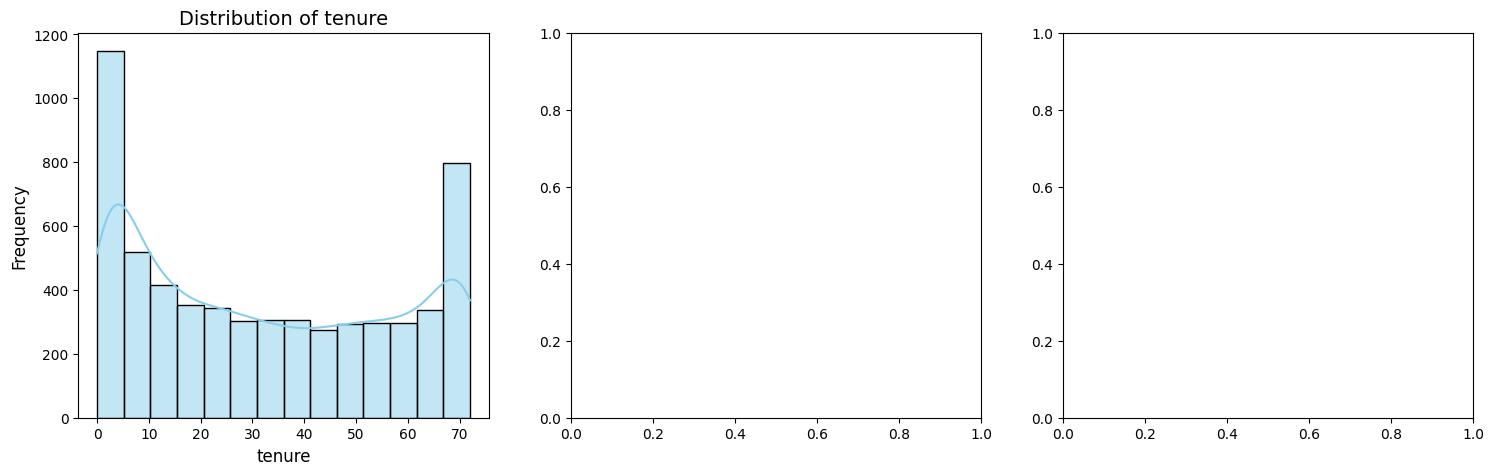

In [68]:

# Distribution of numerical variables
num_cols = ['tenure', 'Monthlycharges', 'TotalCharges']

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loop through the columns and plot
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Frequency', fontsize=12)


In [69]:
# Quick numerical correlation
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True, cmap='coolwarm')

KeyError: "['TotalCharges'] not in index"

In [70]:
# Checking the number of categories each categorical variable has

# Define the categorical columns only
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
            'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
            'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 
            'PaperlessBilling', 'PaymentMethod', 'Churn']

# Loop through them and print the unique values
for col in cat_cols:
    print(f"{col}")
    print(df[col].unique())
    print("\n")

gender
<StringArray>
['Male', 'Female']
Length: 2, dtype: str


Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


Dependents
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


PhoneService
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


MultipleLines
<StringArray>
['Yes', 'No', 'No phone service']
Length: 3, dtype: str


InternetService
<StringArray>
['No', 'Fiber optic', 'DSL']
Length: 3, dtype: str


OnlineSecurity
<StringArray>
['No internet service', 'No', 'Yes']
Length: 3, dtype: str


OnlineBackup
<StringArray>
['No internet service', 'Yes', 'No']
Length: 3, dtype: str


DeviceProtection
<StringArray>
['No internet service', 'Yes', 'No']
Length: 3, dtype: str


TechSupport
<StringArray>
['No internet service', 'No', 'Yes']
Length: 3, dtype: str


StreamingTV
<StringArray>
['No internet service', 'Yes', 'No']
Length: 3, dtype: str


StreamingMovies
<StringArray>
['No internet service', 'No', 'Yes']
Length: 3, dtype: str


Contract
<StringArray>
['Two year', 'Month-t

**Split**

In [71]:
# Train/test split (80/20)
# Separate target
X = df.drop('Churn', axis=1)
y = df['Churn']
    
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify preserves class balance
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (4788, 18), Test shape: (1198, 18)


In [72]:


# Correct column names (check your actual DataFrame columns)
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

categorical_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 
                        'MultipleLines', 'InternetService', 'OnlineSecurity', 
                        'OnlineBackup', 'DeviceProtection', 'TechSupport', 
                        'StreamingTV', 'StreamingMovies', 'Contract', 
                        'PaperlessBilling', 'PaymentMethod']

# Improved transformer with handle_unknown='ignore' and grouping rare categories
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

***Model***

**Baseline**

In [73]:
# Baseline
y_train_mean = y_train.mean()
y_pred_baseline_train = np.full_like(y_train, y_train_mean, dtype=float)
y_pred_baseline_test = np.full_like(y_test, y_train_mean, dtype=float)

# Baseline MAE 
baseline_mae_train = mean_absolute_error(y_train, y_pred_baseline_train)
baseline_mae_test = mean_absolute_error(y_test, y_pred_baseline_test)

print(f"Baseline (mean prediction) – Train MAE: {baseline_mae_train:.4f}")
print(f"Baseline (mean prediction) – Test MAE:  {baseline_mae_test:.4f}")

Baseline (mean prediction) – Train MAE: 0.3896
Baseline (mean prediction) – Test MAE:  0.3898


**Iterate**

In [75]:
numeric_features = ['tenure', 'MonthlyCharges']
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
                        'PhoneService', 'MultipleLines', 'InternetService', 
                        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                        'TechSupport', 'StreamingTV', 'StreamingMovies', 
                        'Contract', 'PaperlessBilling', 'PaymentMethod']

# Preprocessing for numeric: impute median, then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical: impute missing, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Combine
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Full pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Fit on training data
model_pipeline.fit(X_train, y_train)
print("Model trained successfully.")


Model trained successfully.


**Evaluate**

In [83]:
y_pred_train_proba = model_pipeline.predict_proba(X_train)[:, 1]
y_pred_test_proba = model_pipeline.predict_proba(X_test)[:, 1]

train_mae = mean_absolute_error(y_train, y_pred_train_proba)
test_mae = mean_absolute_error(y_test, y_pred_test_proba)

print(f"Model – Train MAE: {train_mae:.4f}")
print(f"Model – Test MAE:  {test_mae:.4f}")
print(f"Improvement over baseline (test): {baseline_mae_test - test_mae:.4f}")

Model – Train MAE: 0.2689
Model – Test MAE:  0.2798
Improvement over baseline (test): 0.1100


In [84]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

y_pred_class = (y_pred_proba >= 0.5).astype(int)

print(f"Accuracy:  {accuracy_score(y_test, y_pred_class):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_class):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_class):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred_class):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.3f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_class))

Accuracy:  0.788
Precision: 0.626
Recall:    0.500
F1-score:  0.556
ROC-AUC:   0.823

Confusion Matrix:
[[785  95]
 [159 159]]


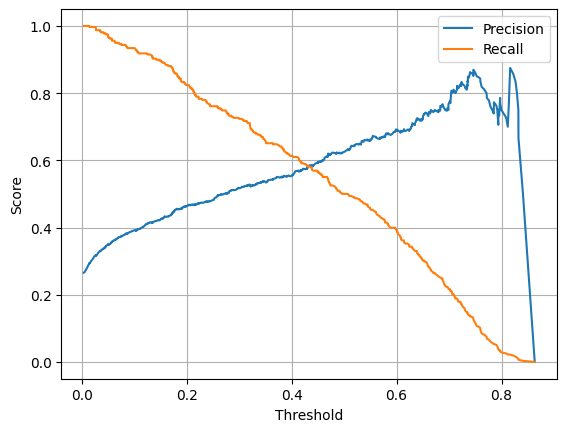

Threshold for recall ~0.7: 0.321
Precision at that threshold: 0.525


In [85]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Plot trade-off
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

# Choose threshold where recall = 0.7 
target_recall = 0.7
idx = np.argmin(np.abs(recalls[:-1] - target_recall))
print(f"Threshold for recall ~{target_recall}: {thresholds[idx]:.3f}")
print(f"Precision at that threshold: {precisions[idx]:.3f}")

***Communicate Result***

*Extract intercept and coefficients*

In [78]:
logreg = model_pipeline.named_steps['classifier']

# Get feature names after one-hot encoding
preprocessor_obj = model_pipeline.named_steps['preprocessor']
num_features = numeric_features
cat_feature_names = preprocessor_obj.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features).tolist()
all_feature_names = num_features + cat_feature_names

intercept = logreg.intercept_[0]
coefficients = logreg.coef_[0]

print(f"Intercept: {intercept:.4f}")
print("\nCoefficients:")
for name, coef in zip(all_feature_names, coefficients):
    print(f"  {name}: {coef:.4f}")

Intercept: -0.6539

Coefficients:
  tenure: -0.7895
  MonthlyCharges: 0.5530
  gender_Male: -0.0851
  SeniorCitizen_1: 0.2535
  Partner_Yes: -0.0320
  Dependents_Yes: -0.0236
  PhoneService_Yes: -0.7082
  MultipleLines_No phone service: 0.1098
  MultipleLines_Yes: 0.2270
  InternetService_Fiber optic: 0.4282
  InternetService_No: -0.0544
  OnlineSecurity_No internet service: -0.0544
  OnlineSecurity_Yes: -0.5162
  OnlineBackup_No internet service: -0.0544
  OnlineBackup_Yes: -0.2952
  DeviceProtection_No internet service: -0.0544
  DeviceProtection_Yes: -0.1190
  TechSupport_No internet service: -0.0544
  TechSupport_Yes: -0.4195
  StreamingTV_No internet service: -0.0544
  StreamingTV_Yes: 0.0446
  StreamingMovies_No internet service: -0.0544
  StreamingMovies_Yes: 0.1743
  Contract_One year: -0.7742
  Contract_Two year: -1.3644
  PaperlessBilling_Yes: 0.3213
  PaymentMethod_Credit card (automatic): -0.1317
  PaymentMethod_Electronic check: 0.3421
  PaymentMethod_Mailed check: 0.0800


First 20 predictions vs actual:
    True_Churn  Predicted_Prob  Residual
0            1        0.794177  0.205823
1            0        0.474185 -0.474185
2            0        0.025717 -0.025717
3            0        0.012674 -0.012674
4            1        0.235625  0.764375
5            0        0.567609 -0.567609
6            0        0.027382 -0.027382
7            0        0.013068 -0.013068
8            1        0.276392  0.723608
9            0        0.061657 -0.061657
10           1        0.665473  0.334527
11           1        0.314292  0.685708
12           0        0.095362 -0.095362
13           0        0.047841 -0.047841
14           0        0.429715 -0.429715
15           0        0.280719 -0.280719
16           0        0.038565 -0.038565
17           0        0.600976 -0.600976
18           0        0.406366 -0.406366
19           0        0.324136 -0.324136


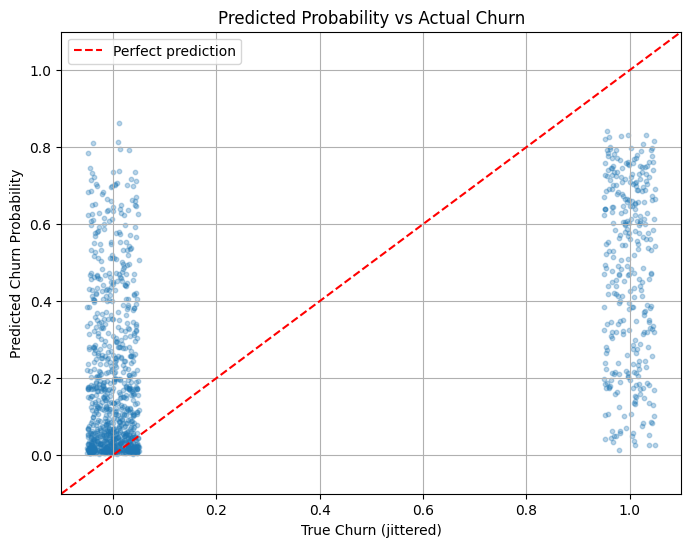

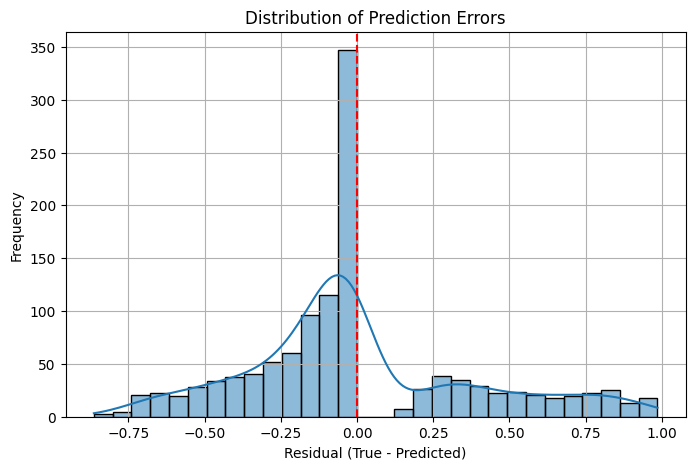

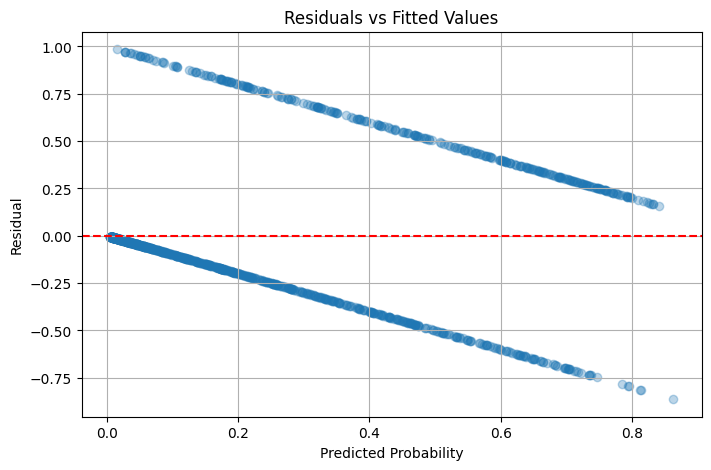

In [82]:


# Get predicted probabilities on test set
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]

# Create a comparison DataFrame
comparison_df = pd.DataFrame({
    'True_Churn': y_test.values if hasattr(y_test, 'values') else y_test,
    'Predicted_Prob': y_pred_proba
})
comparison_df['Residual'] = comparison_df['True_Churn'] - comparison_df['Predicted_Prob']

# 1. Table of first 20 rows
print("First 20 predictions vs actual:")
print(comparison_df.head(20).to_string())

# 2. Scatter plot: True vs Predicted (with jitter for 0/1 points)
plt.figure(figsize=(8,6))
# Add small jitter to true values to see overlapping points
jitter = 0.05
true_jittered = comparison_df['True_Churn'] + np.random.uniform(-jitter, jitter, len(comparison_df))
plt.scatter(true_jittered, comparison_df['Predicted_Prob'], alpha=0.3, s=10)
plt.plot([-0.1, 1.1], [-0.1, 1.1], 'r--', label='Perfect prediction')
plt.xlabel('True Churn (jittered)')
plt.ylabel('Predicted Churn Probability')
plt.title('Predicted Probability vs Actual Churn')
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid(True)
plt.show()

# 3. Residual histogram
plt.figure(figsize=(8,5))
sns.histplot(comparison_df['Residual'], bins=30, kde=True)
plt.xlabel('Residual (True - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.axvline(x=0, color='red', linestyle='--')
plt.grid(True)
plt.show()

# Optional: Residual vs Predicted (heteroscedasticity check)
plt.figure(figsize=(8,5))
plt.scatter(comparison_df['Predicted_Prob'], comparison_df['Residual'], alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Probability')
plt.ylabel('Residual')
plt.title('Residuals vs Fitted Values')
plt.grid(True)
plt.show()

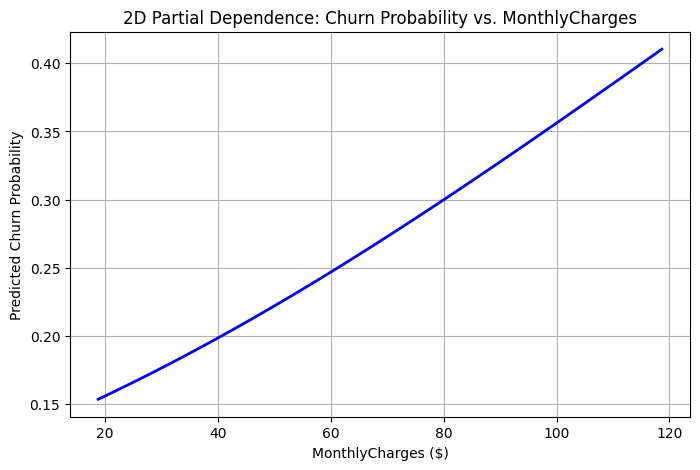

In [79]:
import matplotlib.pyplot as plt

# Create a synthetic test set where only MonthlyCharges varies
X_vis = X_test.copy()
monthly_range = np.linspace(X_test['MonthlyCharges'].min(), X_test['MonthlyCharges'].max(), 100)
probs = []

for m in monthly_range:
    X_vis['MonthlyCharges'] = m
    prob = model_pipeline.predict_proba(X_vis)[:, 1].mean()
    probs.append(prob)

plt.figure(figsize=(8,5))
plt.plot(monthly_range, probs, 'b-', linewidth=2)
plt.xlabel('MonthlyCharges ($)')
plt.ylabel('Predicted Churn Probability')
plt.title('2D Partial Dependence: Churn Probability vs. MonthlyCharges')
plt.grid(True)
plt.show()

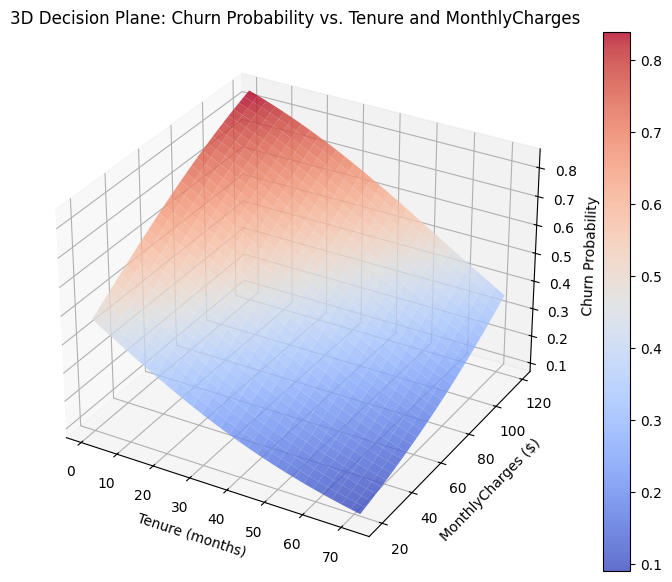

In [81]:

# Create a template row 
template = {}

# Numeric columns: use median
numeric_cols = ['tenure', 'MonthlyCharges']
for col in numeric_cols:
    template[col] = X_test[col].median()

# Categorical columns with mode 
categorical_cols = [col for col in X_test.columns if col not in numeric_cols + ['churn']]
for col in categorical_cols:
    template[col] = X_test[col].mode()[0]

# StCreate grid over tenure and MonthlyCharges
tenure_vals = np.linspace(X_test['tenure'].min(), X_test['tenure'].max(), 30)
monthly_vals = np.linspace(X_test['MonthlyCharges'].min(), X_test['MonthlyCharges'].max(), 30)
T, M = np.meshgrid(tenure_vals, monthly_vals)

#  Predict probability for each point on the grid
probs_grid = np.zeros(T.shape)

for i in range(T.shape[0]):
    for j in range(T.shape[1]):
        # Copy template and override tenure & MonthlyCharges
        row = template.copy()
        row['tenure'] = T[i, j]
        row['MonthlyCharges'] = M[i, j]
        X_row = pd.DataFrame([row])
        probs_grid[i, j] = model_pipeline.predict_proba(X_row)[0, 1]

# Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(T, M, probs_grid, cmap='coolwarm', alpha=0.8)
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('MonthlyCharges ($)')
ax.set_zlabel('Churn Probability')
ax.set_title('3D Decision Plane: Churn Probability vs. Tenure and MonthlyCharges')
fig.colorbar(surf)
plt.show()